In [1]:
"""Lunar Lander : train a Lunar Lander, to land correctly on the moon."""
from pprint import pprint
from typing import NamedTuple

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
from huggingface_sb3 import load_from_hub, package_to_hub
from huggingface_hub import notebook_login 
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import VecEnv, make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from torch import nn, Tensor
from torch.distributions import Categorical
from torch.optim import Adam

# How Gymnasium Works

- We create our environment using `gym.make()`
- We reset the environment to its initial state with `env.reset()`

Then, at each step
- Get an action using our model
- Using `env.step(action)`, we perform this action in the environment and get:
    - `observation` : The new state (st+1)
    - `reward` : The reward we get after executing the action
    - `terminated` : Indicates if the episode terminated (agent reach the terminal state)
    - `truncated` : Indicates a time limit or if an agent go out of bounds of the environment
    - `info` : A dictionary that provides additional information (depends on the environment)

In [2]:
# First, we create our environment called LunarLander-v2
env = gym.make("LunarLander-v2")

# Then we reset this environment
observation, info = env.reset()

# see what the Environment looks like
# The observation is a vector of size 8
# each value contains different information about the lander
print("Observation Space Shape", env.observation_space.shape)

# Get a random observation
observations = env.observation_space.sample()
obs_fields = [
    "x",
    "y", 
    "x_velocity",
    "y_velocity",
    "angle",
    "angular_velocity",
    "left_leg_contact",
    "right_leg_contact"
]
print("Sample observation: ")
pprint(
    dict(zip(obs_fields, env.observation_space.sample(), strict=True)),
    sort_dicts=False
)

# The action space is a discrete space of 4 possible actions
print("\nAction Space Shape", env.action_space.n)
actions = [
    "Do nothing",
    "Fire left orientation engine",
    "Fire main engine",
    "Fire right orientation engine"
]
for i in range(20):
    # Get a random action
    action = env.action_space.sample()

    # Perform the action
    print(f"Step {i:>2} : {actions[action]}")
    observation, reward, terminated, truncated, info = env.step(action)

    # If the game is terminated (in our case we land, crashed) or truncated (timeout)
    if terminated or truncated:
        # Reset the environment
        print("Environment is reset")
        observation, info = env.reset()

env.close()

Observation Space Shape (8,)
Sample observation: 
{'x': 80.28628,
 'y': 73.612366,
 'x_velocity': 1.7773937,
 'y_velocity': -3.9609056,
 'angle': -1.9654112,
 'angular_velocity': 4.2304006,
 'left_leg_contact': 0.17298254,
 'right_leg_contact': 0.8932845}

Action Space Shape 4
Step  0 : Fire left orientation engine
Step  1 : Do nothing
Step  2 : Fire main engine
Step  3 : Fire left orientation engine
Step  4 : Fire left orientation engine
Step  5 : Do nothing
Step  6 : Fire main engine
Step  7 : Fire right orientation engine
Step  8 : Do nothing
Step  9 : Do nothing
Step 10 : Do nothing
Step 11 : Fire right orientation engine
Step 12 : Fire left orientation engine
Step 13 : Fire main engine
Step 14 : Fire left orientation engine
Step 15 : Do nothing
Step 16 : Do nothing
Step 17 : Fire main engine
Step 18 : Do nothing
Step 19 : Do nothing


## Reward function

After every step a reward is granted. The total reward of an episode is the sum of the rewards for all the steps within that episode.

For each step, the reward:
- Is increased/decreased the closer/further the lander is to the landing pad.
- Is increased/decreased the slower/faster the lander is moving.
- Is decreased the more the lander is tilted (angle not horizontal).
- Is increased by 10 points for each leg that is in contact with the ground.
- Is decreased by 0.03 points each frame a side engine is firing.
- Is decreased by 0.3 points each frame the main engine is firing.
- The episode receive an additional reward of -100 or +100 points for crashing or landing safely respectively.

An episode is considered a solution if it scores at least 200 points.

## Vectorized Environment
We create a vectorized environment (stack multiple independent environments into a single environment), this way, we’ll have more diverse experiences during the training.

In [3]:
n_envs = 10
vec_env = make_vec_env("LunarLander-v2", n_envs=n_envs)

observations = []
actions = []
rewards = []

# Restart the environment and get initial observation
observations.append(vec_env.reset())
while True:
    # Sample random actions
    acts_i = torch.randint(0, 4, (n_envs,)).numpy()
    actions.append(acts_i)

    # Perform the actions
    next_obs, rewards_i, done_i, info = vec_env.step(acts_i)
    rewards.append(rewards_i)

    if done_i.any():
        break

    observations.append(next_obs)

observations = torch.from_numpy(np.array(observations))
actions = torch.from_numpy(np.array(actions))
rewards = torch.from_numpy(np.array(rewards))

vec_env.close()

print("Observations shape:", observations.shape)
print("Actions shape:", actions.shape)
print("Rewards shape:", rewards.shape)

Observations shape: torch.Size([63, 10, 8])
Actions shape: torch.Size([63, 10])
Rewards shape: torch.Size([63, 10])


# Simple Policy Network

## Policy Network

In [4]:
class PolicyNet(nn.Module):
    """Simple policy network."""

    def __init__(self, obs_dim: int, act_dim: int, hidden_dim: int) -> None:
        super().__init__()

        self.obs_dim = obs_dim
        self.act_dim = act_dim

        # Define the policy network
        self.pi = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, act_dim)
        )

    def forward(self, observation: Tensor) -> Tensor:
        """Get logits for action space given an observation.

        Parameters
        ----------
        observation: Tensor[..., obs_dim, dtype=float32]
            Observation tensor.

        Returns
        -------
        action_logits: Tensor[..., act_dim, dtype=float32]
            Logits for action space.
        """
        return self.pi(torch.atleast_2d(observation))

    def get_policy(self, observation: Tensor) -> Categorical:
        """Compute probability distribution over actions given an observation.

        Parameters
        ----------
        observation: Tensor[..., obs_dim, dtype=float32]
            Observation tensor.

        Returns
        -------
        policy: Categorical
            Action distribution given the observation.
        """
        logits = self.forward(observation)
        return Categorical(logits=logits)

    def get_action(self, observation: Tensor) -> Tensor:
        """Sample an action from the policy given an observation.

        Parameters
        ----------
        observation : Tensor[..., obs_dim, dtype=float32]
            Observation tensor.

        Returns
        -------
        action: Tensor[..., dtype=int64]
            Sampled action.
        """
        return self.get_policy(observation).sample()

# Create a policy network
model = PolicyNet(
    obs_dim=vec_env.observation_space.shape[0],
    act_dim=vec_env.action_space.n,
    hidden_dim=64
)

model

PolicyNet(
  (pi): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=64, out_features=4, bias=True)
  )
)

In [5]:
# Test model on a batch of observations
print(f"Observations shape: {observations.shape}")

# Get a sample of actions | observations
actions = model.get_action(observations)
print(f"Actions shape: {actions.shape}")

# Get the action distribution
action_dist = model.get_policy(observations)
print(f"Action distribution: {action_dist}")

# Get the log probability of the actions taken
logp: Tensor = action_dist.log_prob(value=actions)
print(f"Action log-probability shape: {logp.shape}")

Observations shape: torch.Size([63, 10, 8])
Actions shape: torch.Size([63, 10])
Action distribution: Categorical(logits: torch.Size([63, 10, 4]))
Action log-probability shape: torch.Size([63, 10])


## Loss function

In [6]:
def compute_loss(
        model: PolicyNet,
        observations: Tensor,
        actions: Tensor,
        weights: Tensor
    ) -> Tensor:
    """Compute the policy gradient loss from a batch of (obs, action, weight) triples.

    - the (obs, action, weight) triples are collected while acting according
    to the current policy over the course of an episode (or several episodes).
    - the weight for a observation-action pair is the return from the episode
    to which it belongs.

    Parameters
    ----------
    model: PolicyNet
        The policy network
    observations: Tensor[..., obs_dim, dtype=float32]
        A batch of observations
    actions: Tensor[..., dtype=int64]
        A batch of actions
    weights: Tensor[..., dtype=float32]
        Episode return for each state-action pair.

    Returns
    -------
    Tensor[1]
        The policy gradient loss
    """
    # Validate the shape of inputs
    if observations.shape[:-1] != actions.shape:
        raise ValueError("# Observations must match # actions")
    if observations.shape[:-1] != weights.shape:
        raise ValueError("# Observations must match # weights")

    # Get action probability distribution given observation
    action_dist = model.get_policy(observations)

    # Compute log probability of the action
    logp: Tensor = action_dist.log_prob(value=actions)

    # Compute the policy gradient loss
    return -(logp * weights).mean()

In [7]:
def get_reward_to_go_weights(rewards: Tensor) -> Tensor:
    """Compute the reward-to-go weights from a batch of rewards.

    Rewards obtained before taking an action have no bearing on how good
    that action was; only rewards that come after.

    Parameters
    ----------
    rewards: Tensor[n_steps, n_envs, dtype=float32]
        A sequence of rewards from an episode (per environment).

    Returns
    -------
    Tensor[..., dtype=float32]
        The reward-to-go weights for each step in the sequence.

    Example
    -------
    >>> import torch
    >>> rewards = torch.tensor(
    ...     [[ 2.4491,  1.2703], [-0.9930, -0.8285], [3.4893, -5.6373]]
    ... )
    >>> get_reward_to_go_weights(rewards)
    tensor([[ 4.9454, -5.1955],
            [ 2.4963, -6.4658],
            [ 3.4893, -5.6373]])
    """
    # Compute the reward-to-go weights
    return rewards.flip(dims=(0,)).cumsum(dim=0).flip(dims=(0,))

In [8]:
# Compute the reward-to-go weights
weights = get_reward_to_go_weights(rewards)

# Compute the policy gradient loss
loss = compute_loss(model, observations, actions, weights)

## Train the policy network

In [9]:
class EpisodeSummary(NamedTuple):
    """Summary of an episode.

    Attributes
    ----------
    num_steps: int
        Number of steps in the episode.
    avg_return: float
        Average return over the episode.
    avg_total_reward: float
        Average total reward over the episode.
    total_rewards: np.ndarray
        Total rewards for each environment in the episode.
    """

    num_steps: int
    avg_return: float
    avg_total_reward: float
    total_rewards: np.ndarray


def train_for_one_epoch(
    env: VecEnv,
    model: PolicyNet,
    optimizer: Adam,
    device: torch.device,
    *,
    max_steps: int = 200,
    timeout_pentalty: float = 0.0
) -> EpisodeSummary:
    """Train the policy network for one epoch.

    Parameters
    ----------
    env: VecEnv
        The environment
    model: PolicyNet
        The policy network
    optimizer: Adam
        The optimizer
    """
    # Collect observations, actions, and rewards over the episode
    observations = []
    actions = []
    rewards = []

    # Reset environment and get initial observation
    obs = env.reset()

    # Collect observations, actions, and rewards over the episode
    for _ in range(max_steps):
        # Convert observation to tensor and move to device
        obs = torch.from_numpy(obs).to(device)
        observations.append(obs)

        # get action | obs
        act = model.get_action(obs)
        actions.append(act)

        # Perform the actions
        obs, reward, done, info = env.step(act.cpu().numpy())
        rewards.append(torch.from_numpy(reward).to(device))

        # Check if any of the environments have reach end of episode
        if done.any():
            break
    else:
        # Reached the time limit, add a penalty to the rewards
        rewards[-1] += timeout_pentalty

    # Stack episode steps together into a batch
    observations = torch.stack(observations, dim=0)
    actions = torch.stack(actions, dim=0)
    rewards = torch.stack(rewards, dim=0)

    # Compute the reward-to-go weights
    weights = get_reward_to_go_weights(rewards)

    # Compute the policy gradient loss
    loss = compute_loss(model, observations, actions, weights)

    # Optimize the policy network
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Return the episode summary
    total_rewards: np.ndarray = rewards.sum(1).cpu().numpy()
    return EpisodeSummary(
        num_steps=len(rewards),
        avg_return=rewards.mean().item(),
        avg_total_reward=total_rewards.mean(),
        total_rewards=total_rewards,
    )

In [11]:
# Initialize vectorized environment
n_envs = 32
vec_env = make_vec_env("LunarLander-v2", n_envs=n_envs)

# Create a policy network
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print (f"Using device: {device}")
model = PolicyNet(
    obs_dim=vec_env.observation_space.shape[0],
    act_dim=vec_env.action_space.n,
    hidden_dim=64
)
model.to(device)

# Create an optimizer
optimizer = Adam(model.parameters(), lr=1e-3)

Using device: cuda


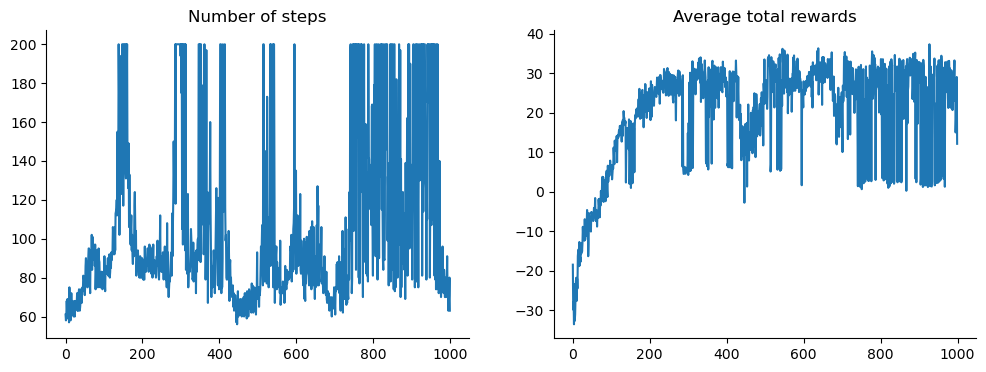

In [12]:
num_steps = []
avg_total_rewards = []
n_epochs = 1_000
timeout_penalty = np.linspace(-50.0, -100.0, n_epochs)
for epoch in range(1_000):
    episode_summary = train_for_one_epoch(
        vec_env, model, optimizer, device, timeout_pentalty=timeout_penalty[epoch]
    )
    num_steps.append(episode_summary.num_steps)
    avg_total_rewards.append(episode_summary.avg_total_reward)
    print(
        f"Epoch {epoch:>6}: "
        f"{np.median(num_steps[-30:]):>5.0f} "
        f"{np.median(avg_total_rewards[-30:]):>5.1f}",
        flush=True,
        end="\r"
    )

_, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(num_steps)
axs[0].set_title("Number of steps")
axs[0].spines["right"].set_visible(False)
axs[0].spines["top"].set_visible(False)

axs[1].plot(avg_total_rewards)
axs[1].set_title("Average total rewards")
axs[1].spines["right"].set_visible(False)
axs[1].spines["top"].set_visible(False)

#  Proximal Policy Optimization